In [1]:
import kagglehub

path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

print("Path to dataset files:",path)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/twitter-entity-sentiment-analysis


In [12]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
path=kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")
print("Path to dataset files:",path)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/twitter-entity-sentiment-analysis


In [14]:
# Define column names
column_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']

# Load only the training data
train_df = pd.read_csv(os.path.join(path, 'twitter_training.csv'), header=None, names=column_names)

In [15]:
train_df = train_df.dropna(subset=['Tweet'])

# Save the cleaned version to your local folder/Colab
train_df.to_csv('cleaned_twitter_training.csv', index=False)
print("\n✅ Cleaned data saved as 'cleaned_twitter_training.csv'")


✅ Cleaned data saved as 'cleaned_twitter_training.csv'



Generating Visualizations...


/tmp/ipykernel_1899/1052140551.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


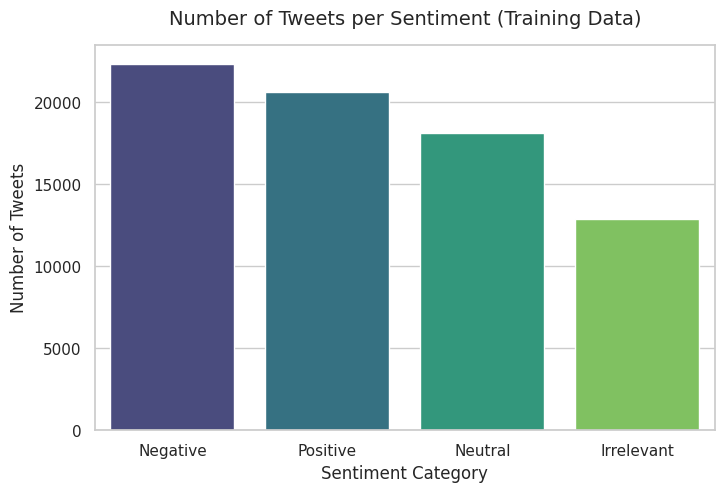

In [16]:
sns.set_theme(style="whitegrid")

# --- Chart 1: Class Distribution ---
print("\nGenerating Visualizations...")
fig1, ax1 = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=train_df,
    x='Sentiment',
    order=train_df['Sentiment'].value_counts().index,
    palette='viridis',
    ax=ax1
)
ax1.set_title('Number of Tweets per Sentiment (Training Data)', fontsize=14, pad=15)
ax1.set_xlabel('Sentiment Category', fontsize=12)
ax1.set_ylabel('Number of Tweets', fontsize=12)
plt.show()

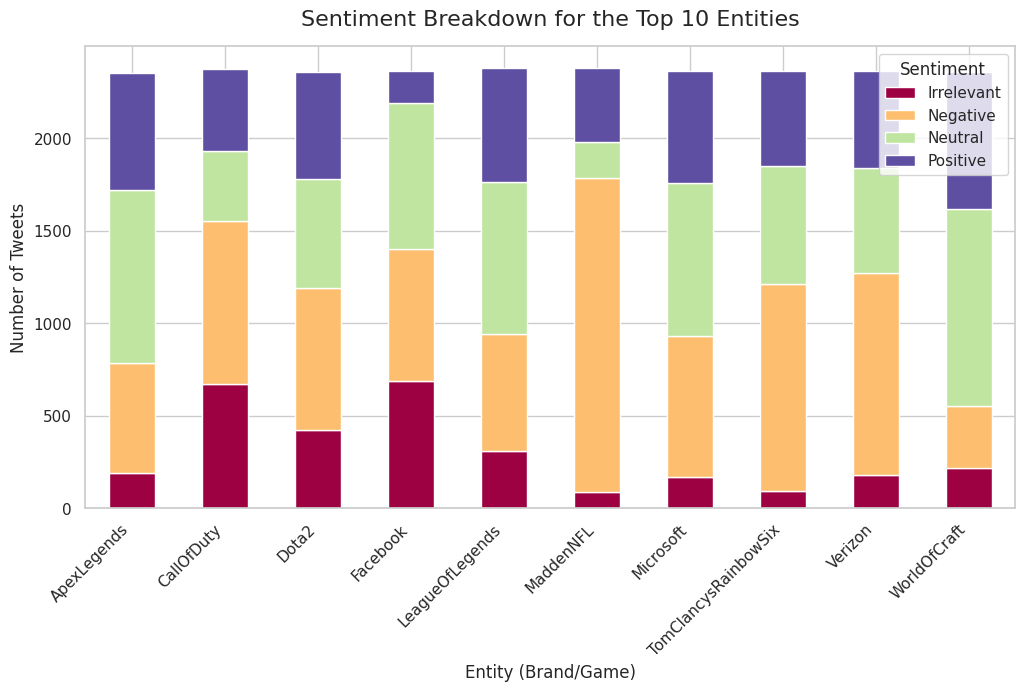

In [17]:
top_10_entities = train_df['Entity'].value_counts().nlargest(10).index
top_entities_df = train_df[train_df['Entity'].isin(top_10_entities)]
entity_sentiment_counts = top_entities_df.groupby(['Entity', 'Sentiment']).size().unstack(fill_value=0)

fig2, ax2 = plt.subplots(figsize=(12,6))
entity_sentiment_counts.plot(kind='bar', stacked=True, ax=ax2, colormap='Spectral')
ax2.set_title('Sentiment Breakdown for the Top 10 Entities', fontsize=16, pad=15)
ax2.set_xlabel('Entity (Brand/Game)', fontsize=12)
ax2.set_ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.show()

In [18]:
X = train_df['Tweet']
y = train_df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining the Random Forest Classifier...")
model = make_pipeline(
    TfidfVectorizer(max_features=2500), # Cut in half for speed
    RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42) # 50 trees is plenty
)

# Train the model
model.fit(X_train, y_train)

# Test the model
predictions = model.predict(X_test)

print("\n--- Final Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%\n")
print(classification_report(y_test, predictions))


Training the Random Forest Classifier...

--- Final Model Evaluation ---
Accuracy: 87.82%

              precision    recall  f1-score   support

  Irrelevant       0.95      0.79      0.86      2696
    Negative       0.87      0.92      0.89      4380
     Neutral       0.90      0.87      0.88      3605
    Positive       0.83      0.91      0.87      4119

    accuracy                           0.88     14800
   macro avg       0.89      0.87      0.88     14800
weighted avg       0.88      0.88      0.88     14800



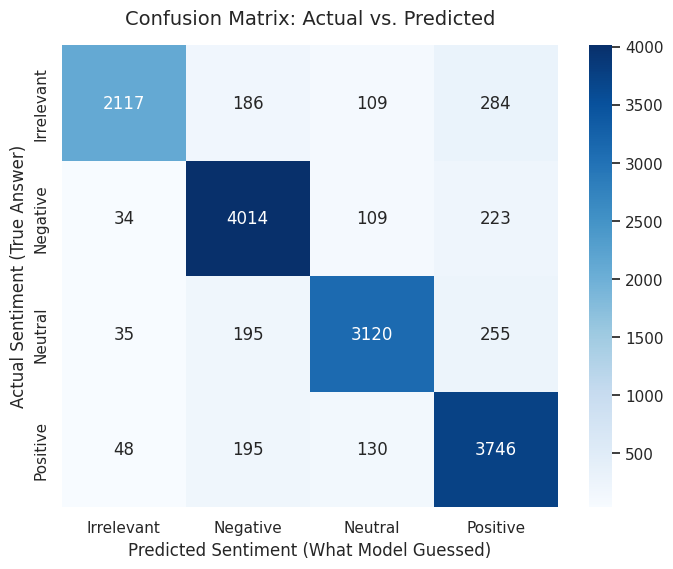

In [19]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_)

fig3, ax3 = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    ax=ax3
)
ax3.set_title('Confusion Matrix: Actual vs. Predicted', fontsize=14, pad=15)
ax3.set_xlabel('Predicted Sentiment (What Model Guessed)', fontsize=12)
ax3.set_ylabel('Actual Sentiment (True Answer)', fontsize=12)
plt.show()

In [20]:
# Load the separate validation file
valid_df = pd.read_csv(os.path.join(path, 'twitter_validation.csv'), header=None, names=column_names)

# Clean it exactly the same way we cleaned the training data
valid_df = valid_df.dropna(subset=['Tweet'])

# Let the trained model guess the sentiments!
final_predictions = model.predict(valid_df['Tweet'])

print("--- Ultimate Validation Score ---")
print(f"Final Real-World Accuracy: {accuracy_score(valid_df['Sentiment'], final_predictions) *100:.2f}%\n")

--- Ultimate Validation Score ---
Final Real-World Accuracy: 93.80%

